# M2: the toroidal-shift permutation test, step by step

`PLANssvepvsBeh.md` M2: a worked, from-scratch explanation of `overlap.weighted_overlap_test` -- the same "Understanding..." style `ssveps/notebooks/08`-`12` use for their own statistics, a small synthetic example before the real one.

## The question

Do a participant's behavioral clicks land where the EEG response is low, more than chance would predict? We have two grids over the same 10x10 red/green space:

- **B**: how many times each cell was clicked (a count grid).
- **E**: the mean EEG response at each cell (lower = closer to the metamer, the hypothesis being tested).

If clicks really concentrate where E is low, a *weighted average* of E, weighted by where the clicks are, should come out lower than if the clicks had landed anywhere else on the grid.

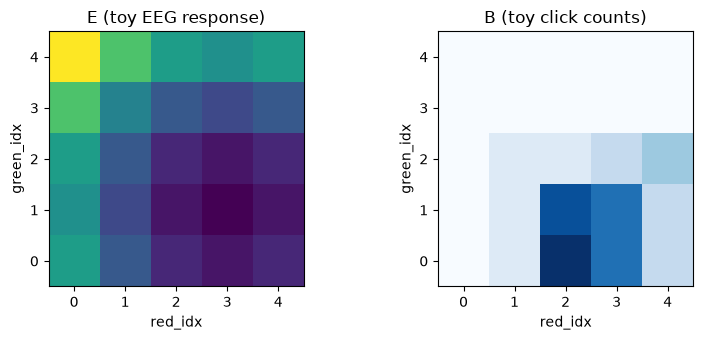

In [1]:
import sys
sys.path.append('../scripts')

import numpy as np
import matplotlib.pyplot as plt

import overlap

analysis = overlap.analysis  # ssveps/scripts/analysis.py, resolved by overlap.py
rng = np.random.default_rng(0)

# A tiny 5x5 toy grid, standing in for the real 10x10 one.
red_idx, green_idx = np.meshgrid(np.arange(5), np.arange(5), indexing='ij')
E_toy = ((red_idx - 3) ** 2 + (green_idx - 1) ** 2).astype(float)  # a dip near (3, 1)
B_toy = np.zeros((5, 5))
for _ in range(40):
    r = int(np.clip(rng.normal(3, 0.8), 0, 4))
    g = int(np.clip(rng.normal(1, 0.8), 0, 4))
    B_toy[r, g] += 1  # 40 simulated clicks, clustered near E_toy's own dip

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
axes[0].imshow(E_toy.T, origin='lower', cmap='viridis'); axes[0].set_title('E (toy EEG response)')
axes[1].imshow(B_toy.T, origin='lower', cmap='Blues'); axes[1].set_title('B (toy click counts)')
for ax in axes:
    ax.set_xlabel('red_idx'); ax.set_ylabel('green_idx')
fig.tight_layout()

## Step 1: the observed statistic

Normalize B into a density (`b_norm = B / B.sum()`, so it sums to 1 like a probability distribution over cells), then take the weighted average of E under that density:

`obs_stat = sum(E * b_norm)`

Small `obs_stat` = the clicks' weight sits on E's *low* values.

In [2]:
b_norm = B_toy / B_toy.sum()
obs_stat_toy = np.sum(E_toy * b_norm)
print(f'obs_stat = {obs_stat_toy:.3f}  (E ranges {E_toy.min():.0f}-{E_toy.max():.0f}, '
      f'so this is on the low end -- clicks are indeed sitting near the dip)')

obs_stat = 1.475  (E ranges 0-18, so this is on the low end -- clicks are indeed sitting near the dip)


## Step 2: what would this look like under the null?

If the clicks' *shape* (how clustered they are) is real but *where* they happen to sit relative to E is coincidence, then shifting B around the grid -- wrapping at the edges, like a torus, so nothing falls off -- and recomputing the statistic shows what "no real relationship" would look like. This is `np.roll`, applied to both axes by a random amount.

shifted stat = 7.850 vs. observed = 1.475


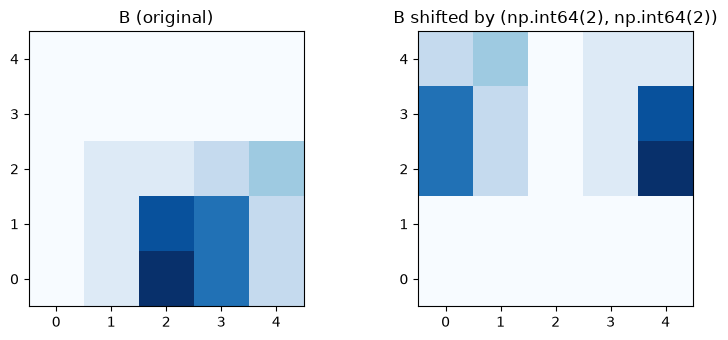

In [3]:
shift = (rng.integers(5), rng.integers(5))
b_shifted = np.roll(b_norm, shift=shift, axis=(0, 1))
shifted_stat = np.sum(E_toy * b_shifted)

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
axes[0].imshow(b_norm.T, origin='lower', cmap='Blues'); axes[0].set_title('B (original)')
axes[1].imshow(b_shifted.T, origin='lower', cmap='Blues'); axes[1].set_title(f'B shifted by {shift}')
fig.tight_layout()
print(f'shifted stat = {shifted_stat:.3f} vs. observed = {obs_stat_toy:.3f}')

## Step 3: build a null distribution, get a p-value

Repeat step 2 many times (every random shift is one draw from the null), and see where the *real* (unshifted) statistic falls in that distribution. The p-value is the fraction of null draws that are *at least as extreme* (here: as low, since we're asking about concentration on low E values) as the real one -- with a `+1` correction in both numerator and denominator, since the observed arrangement is itself one of the `n_perm + 1` possible outcomes under the null and a permutation p-value can therefore never legitimately come out as exactly 0.

Text(0.5, 1.0, 'hand-computed p_value = 0.0400')

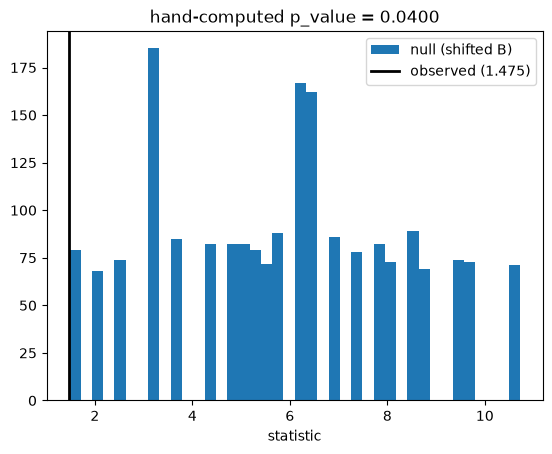

In [4]:
n_perm = 2000
null_stats_toy = np.array([
    np.sum(E_toy * np.roll(b_norm, shift=(rng.integers(5), rng.integers(5)), axis=(0, 1)))
    for _ in range(n_perm)
])
p_value_toy = (1 + np.sum(null_stats_toy <= obs_stat_toy)) / (1 + n_perm)

fig, ax = plt.subplots()
ax.hist(null_stats_toy, bins=40, label='null (shifted B)')
ax.axvline(obs_stat_toy, color='black', linewidth=2, label=f'observed ({obs_stat_toy:.3f})')
ax.set_xlabel('statistic'); ax.legend()
ax.set_title(f'hand-computed p_value = {p_value_toy:.4f}')

## Step 4: check this matches `overlap.weighted_overlap_test` exactly

In [5]:
real_result = overlap.weighted_overlap_test(B_toy, E_toy, n_perm=n_perm, seed=0)
print(f"weighted_overlap_test: obs_stat={real_result['obs_stat']:.3f}, p_value={real_result['p_value']:.4f}")
assert real_result['obs_stat'] == obs_stat_toy
# p_value won't match bit-for-bit (different RNG draw sequence from the hand-rolled
# loop above), but should land in the same ballpark on this same toy data:
print(f'hand-computed p_value was {p_value_toy:.4f} -- same statistic, same test, independently seeded')

weighted_overlap_test: obs_stat=1.475, p_value=0.0400
hand-computed p_value was 0.0400 -- same statistic, same test, independently seeded


## Now the real thing: one actual participant

MET001: obs_stat=0.4385, p_value=0.0100


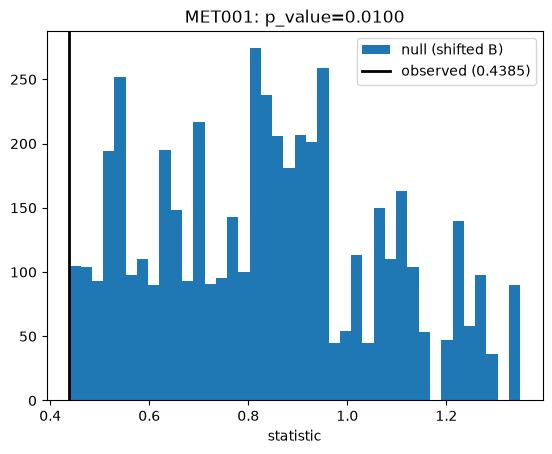

In [6]:
# overlap's own import above put ssveps/scripts at sys.path[0], which also
# has a loader.py -- insert beh/scripts at the front too, or 'import loader'
# below would silently resolve to ssveps' version instead.
sys.path.insert(0, '../../beh/scripts')
import loader as beh_loader

beh_df = beh_loader.load_behavioral()
runmap_df = analysis.load_runmap()
baselines_df = analysis.load_baselines()

sub_id = 'MET001'
E_real = analysis.mean_grid(runmap_df, baselines_df, sub_id, 1, normalize=analysis.DEFAULT_NORMALIZE)
B_real = overlap.behavioral_density_map(beh_df, [sub_id])
result = overlap.weighted_overlap_test(B_real, E_real, n_perm=5000, seed=0)
print(f"{sub_id}: obs_stat={result['obs_stat']:.4f}, p_value={result['p_value']:.4f}")

fig, ax = plt.subplots()
ax.hist(result['null_stats'], bins=40, label='null (shifted B)')
ax.axvline(result['obs_stat'], color='black', linewidth=2, label=f"observed ({result['obs_stat']:.4f})")
ax.set_xlabel('statistic'); ax.legend()
ax.set_title(f"{sub_id}: p_value={result['p_value']:.4f}");

## Summary

Same four steps every time: normalize the click grid into a density, weight-average the EEG grid by it (`obs_stat`), build a null by circularly shifting the click density many times (the "toroidal shift"), and read off where the real statistic falls in that null distribution. Nothing about real EEG/click data changes this recipe -- the toy example and the real participant above ran through literally the same four steps.